--- Mask Validation Summary ---
Total Grid Cells (Lat x Lon): 27648
Valid Ocean Cells (True):     18292 (66.2%)
NaN Land Cells (False):       9356


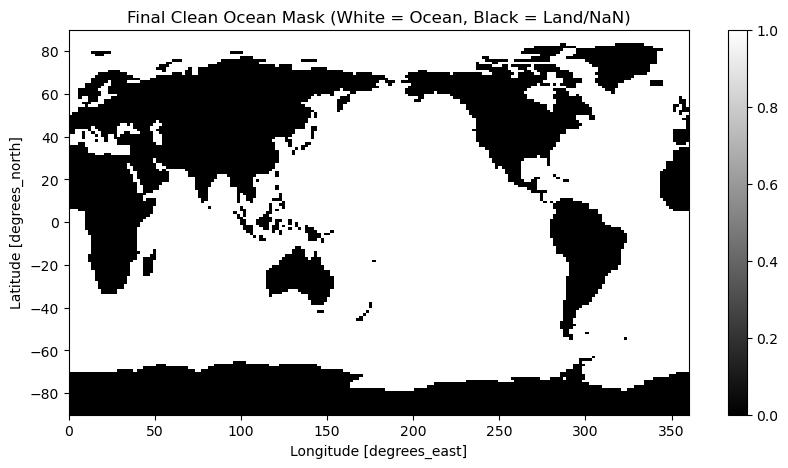

In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import regionmask
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import unary_union
from scipy.ndimage import binary_dilation, zoom
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature



### These are needed to regrid tos data to the same format as atmospheric grids, as well as extract an ocean mask for excluding NaNs from PCA, modelling, etc.
def set_regridder(tos, tas):
    grid_in = tos.isel(time=0).rename({"latitude": "lat", "longitude": "lon"})
    grid_out = tas.isel(time=0)
    regridder = xe.Regridder(grid_in, grid_out, method="nearest_s2d", periodic=True)
    return regridder
def regrid_tos(tos, regridder=None):
    if regridder is None:
        # Fallback to the globally instantiated weight matrix directly
        regridder = globals().get('global_regridder', None)
        if regridder is None:
            raise ValueError("🚨 No valid xESMF regridder was passed or found in global memory!")
    tos_renamed = tos.rename({"latitude": "lat", "longitude": "lon"})
    tos_regridded = regridder(tos_renamed["tos"])
    #tos_regridded.isel(time=0).plot(figsize=(10, 6), cmap="coolwarm")
    return tos_regridded
def get_ocean_mask(tos_regridded):
    ocean_mask = np.isfinite(tos_regridded['tos'].isel(year=0)) # by this stage, the datasets should be processed into years, not just time, otherwise we would write 'time=0'
    total_grid_pixels = ocean_mask.size  # 144 * 192 = 27,648
    active_ocean_pixels = int(ocean_mask.sum())
    ocean_mask.plot(figsize=(8, 5), cmap="gray")
    return ocean_mask
def get_ocean_mask_fixed():
    global regridded
    tos_path = "/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Omon/tos/gn/latest/*nc"
    tos534 = xr.open_mfdataset(tos_path)
    regridded = regrid_tos(tos534).isel(time=0)
    ocean_mask = np.isfinite(regridded) # by this stage, the datasets should be processed into years, not just time, otherwise we would write 'time=0'
    return ocean_mask

def plot_ocean_mask(ocean_mask):
    total_pixels = ocean_mask.size  # 144 * 192 = 27648
    active_ocean_pixels = int(ocean_mask.sum())
    nan_land_pixels = total_pixels - active_ocean_pixels
    
    print("--- Mask Validation Summary ---")
    print(f"Total Grid Cells (Lat x Lon): {total_pixels}")
    print(f"Valid Ocean Cells (True):     {active_ocean_pixels} ({active_ocean_pixels/total_pixels*100:.1f}%)")
    print(f"NaN Land Cells (False):       {nan_land_pixels}")
    
    # 5. Visualise the mask to verify coastlines and Antarctica are perfectly blacked out
    plt.figure(figsize=(10, 5))
    ocean_mask.plot(cmap="gray")
    plt.title("Final Clean Ocean Mask (White = Ocean, Black = Land/NaN)")
    plt.show()

global_regridder = set_regridder(
    xr.open_mfdataset("/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Omon/tos/gn/latest/*nc", 
                      chunks={'time': 12}, combine='by_coords', data_vars='minimal', coords='minimal', compat='override'), # our ocean dataset
    xr.open_mfdataset("/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc") # our atmospheric template to map to
)
ocean_mask = get_ocean_mask_fixed()
plot_ocean_mask(ocean_mask)

In [2]:
# load rmse for baseline, gp, lstm-gp from files
multi = np.load("baseline_and_gps.npz")
baseline_rmse = multi["baseline"]
gp_rmse = multi["gp"]
lstm_rmse = np.load("lstm_gp.npy")

In [3]:
remove_ocean = True  # Activates  specific ocean exclusion mask
merge_regions = True
plot_outlines = True
conts = [
    [3,4,5], # USA
    [9,10,11,12], # Amazon
    [1,2], # Alaska/Canada
    [39,40,41,42] # Australia
    
]
colours = ['purple', 'blue', 'teal', 'magenta']

# 1. Load the raw geospatial grid data natively
forest_data = rioxarray.open_rasterio("High_Res_Forest_Map_Scaled.tif")
forest_grid = forest_data.squeeze()

forest_map_params = {
    'cmap':"YlGn",
    'cbar_kwargs':{'label': 'Canopy Height (m)'}
}

pop_data = rioxarray.open_rasterio("High_Res_Population_Map_Scaled.tif")
pop_grid = pop_data.squeeze()

pop_map_params = {
    'cmap':"YlOrRd",
    'vmin':0,
    'vmax':200,
    'cbar_kwargs':{'label': 'Population Density (people/km²)'}
}

soil_data = rioxarray.open_rasterio("High_Res_SoilMoisture_Map_Scaled.tif")
soil_grid = soil_data.squeeze()
# OPTION A: THE SCIENTIFIC SPECTRUM (Recommended for  chapters): Uses a clean moisture gradient from yellow (parched) to blue/purple (saturated)
soil_map_params_scientific = {
    'cmap': "YlOrBr",   # Yellow to deep earth-brown
    'vmin': 0.05,
    'vmax': 0.40,
    'cbar_kwargs': {'label': 'Volumetric Soil Moisture ($m^3/m^3$)'}
}
    

# OPTION B: THE GEE ALIGNMENT SPECTRUM: Replicates the exact red/yellow/blue/purple style from  Google Earth Engine console
gee_palette = ['red', 'yellow', 'green', 'blue', 'purple']
gee_cmap = LinearSegmentedColormap.from_list("gee_moisture", gee_palette)
soil_map_params_gee = {
    'cmap': gee_cmap,
    'vmin': 0.00,
    'vmax': 0.40,
    'cbar_kwargs': {'label': 'Volumetric Soil Moisture ($m^3/m^3$)'}
}

# Retains  original temperature scale bounds exactly
vmax_error = 2.5
vmax_delta = 1.0
vmin_delta = -1.0
cbar_label = 'Absolute Error (°C)'
delta_label = 'DKL Performance Margin (°C)\n[Blue = DKL Wins | Red = Baseline Wins]'
fmt_cbar = None  # Standard linear colorbar labels

In [4]:
def plot_raster(raster_grid=forest_grid, 
                initial_map_params={}, 
                title="High Resolution Forest Canopy Height with Land-Constrained AR6 Bounds"):
    global ocean_mask_shifted
    # Plotting
    plt.figure(figsize=(15, 6))
    
    # A. Plot the forest canopy as  base layer
    raster_grid.plot(**initial_map_params)
    
    # B. Draw the outlines on top using the pixel mask approach
    if plot_outlines:
        # Generate the 2D integer region mask directly matching  raster dimensions
        land_regions_grid = regionmask.defined_regions.ar6.land.mask(raster_grid.x.values, raster_grid.y.values)
        mask_values = land_regions_grid.values
        if remove_ocean:
            ocean_mask_shifted = globals().get('ocean_mask_shifted', None)
            if ocean_mask_shifted is None:
                # A. Create a copy of climate ocean mask to protect the original variable
                ocean_mask_shifted = ocean_mask.copy(deep=True)
                ocean_mask_shifted = ocean_mask_shifted.astype(float)
                # B. Shift longitudes from standard to match [-180, 180] raster bounds
                adjusted_lon = np.where(ocean_mask_shifted.lon.values > 180, 
                                        ocean_mask_shifted.lon.values - 360, 
                                        ocean_mask_shifted.lon.values)
                ocean_mask_shifted = ocean_mask_shifted.assign_coords(lon=adjusted_lon)
                # C. Sort the longitude coordinates so Xarray can safely track the scale
                ocean_mask_shifted = ocean_mask_shifted.sortby('lon')
                # D. Rename the coordinates so they match the high-res raster names
                ocean_mask_shifted = ocean_mask_shifted.rename({'lon': 'x', 'lat': 'y'})
            # E. Interpolate using true geographical coordinates
            ocean_mask_raster = ocean_mask_shifted.interp_like(raster_grid, method="nearest")
            # F. Convert the properly aligned high-res matrix back into a true Boolean array
            # Where the upscaled mask equals 1.0, it becomes True (Land), else False (Ocean)
            is_land_bool = (ocean_mask_raster.values == 1.0)
        for i in range(len(conts)):
            target_ids = conts[i]
            # Extract the boolean mask for the targeted cluster of region numbers
            combined_region_mask = np.isin(mask_values, target_ids)
            if remove_ocean:
                # Both matrices are now exactly 3118 x 8016, allowing a perfect intersection
                combined_region_mask = combined_region_mask & ~is_land_bool
            # Use binary edge dilation to find the exact outline pixels
            thick_mask = binary_dilation(combined_region_mask, iterations=1)
            outline_mask = thick_mask & ~combined_region_mask
            # Find the row (y) and column (x) matrix indices where outline_mask is True
            row_indices, col_indices = np.where(outline_mask)
            # Map matrix indices back to true Lon/Lat degrees
            x_degrees = forest_grid.x.values[col_indices]
            y_degrees = forest_grid.y.values[row_indices]
            # Overlay the distinct coordinates as colored pixels using scatter
            plt.scatter(x_degrees, y_degrees, color=colours[i], s=1, marker='s', zorder=5)
    
    # Adjust plot view window
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-180, 180)
    plt.ylim(-60, 80)
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Longitude (degrees)", fontsize=11)
    plt.ylabel("Latitude (degrees)", fontsize=11)
    plt.show()

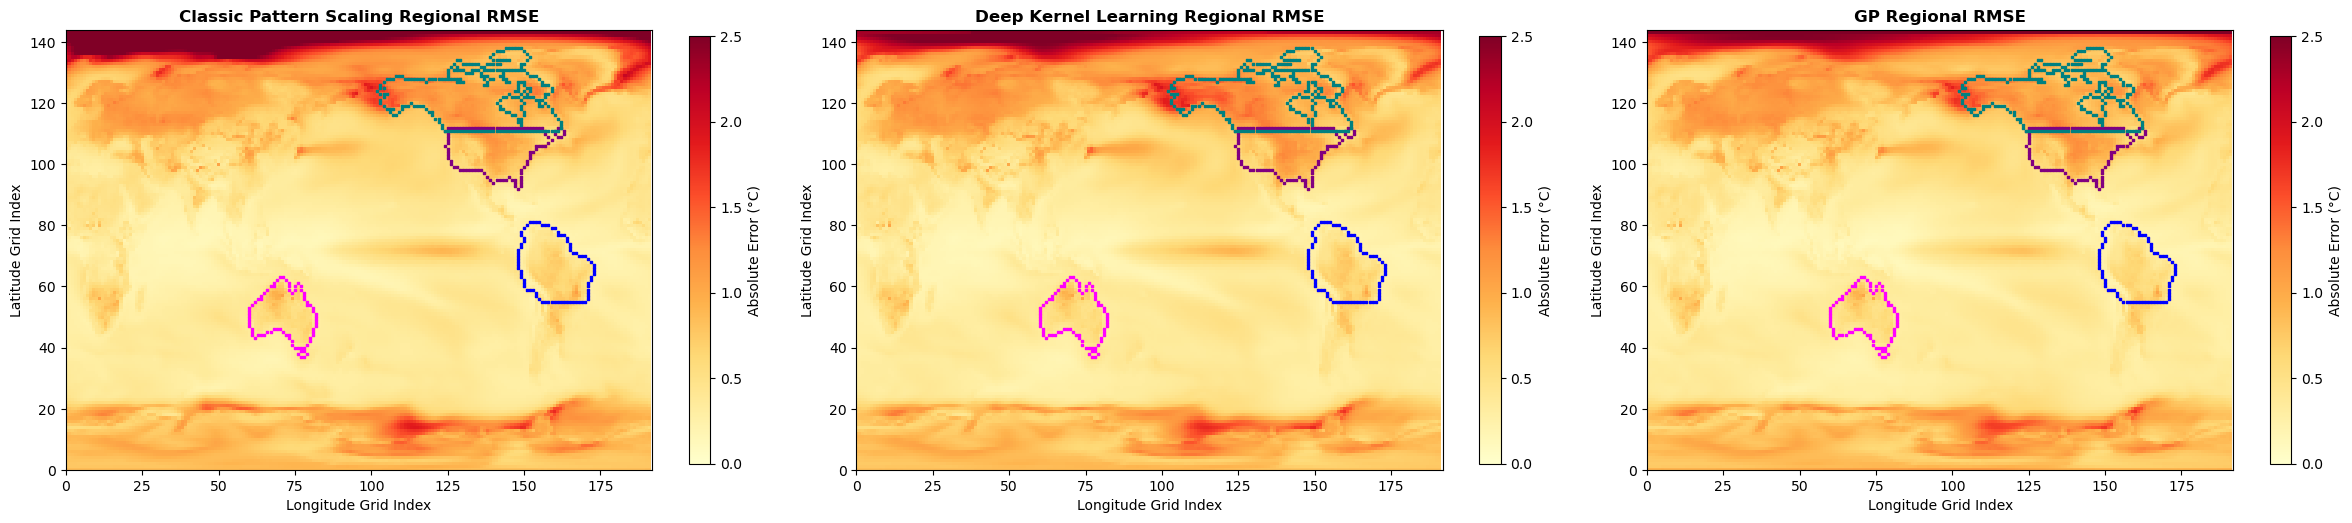

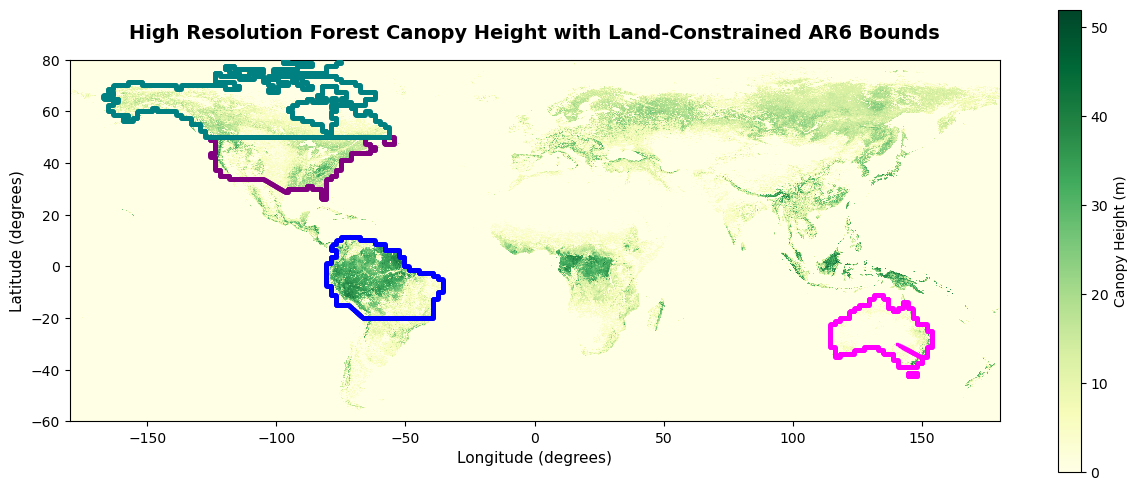

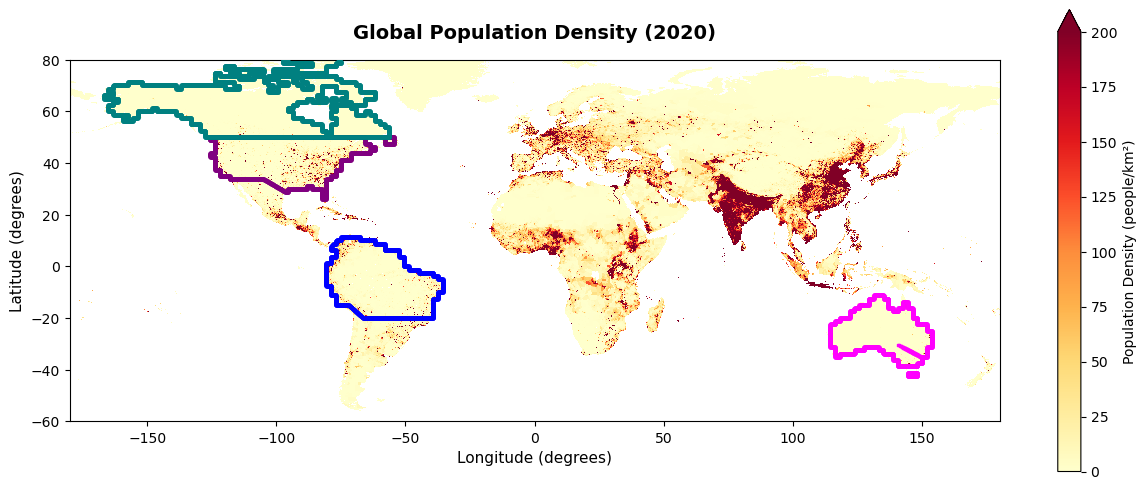

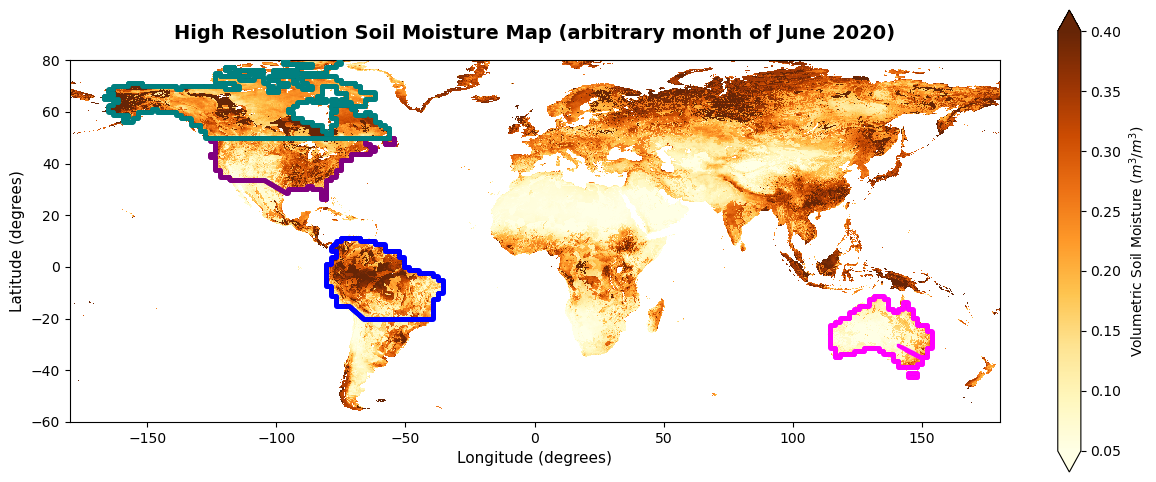

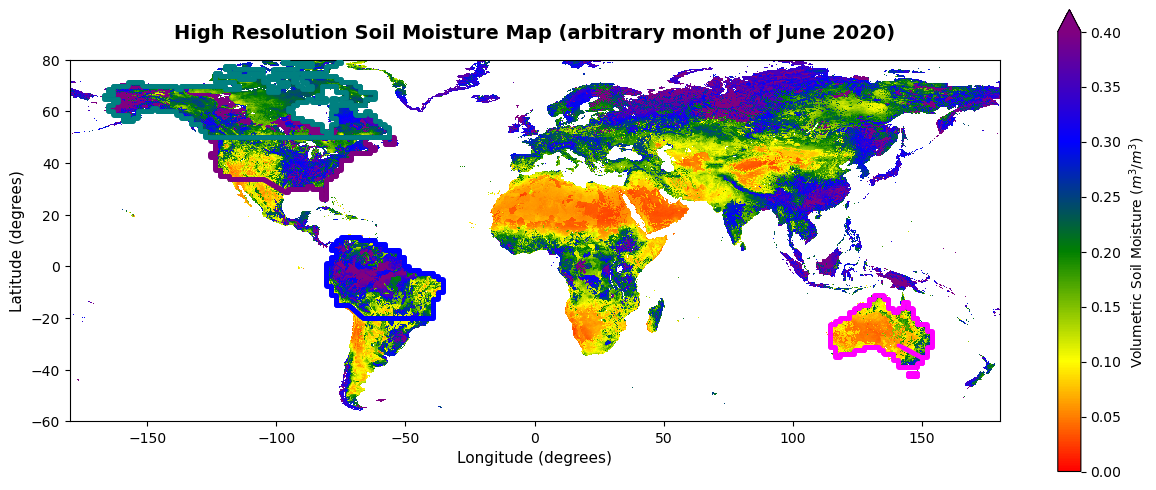

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

vmax_error = 2.5
cbar_label = 'Absolute Error (°C)'
fmt_cbar = None  

# Render Plot 1: Classic Pattern Scaling Map
im0 = axes[0].imshow(baseline_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
cbar0 = fig.colorbar(im0, ax=axes[0], label=cbar_label, shrink=0.75, format=fmt_cbar)

# Render Plot 2: Deep Kernel Learning Map
im1 = axes[1].imshow(lstm_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[1].set_title('Deep Kernel Learning Regional RMSE', fontweight='bold', fontsize=12)
cbar1 = fig.colorbar(im1, ax=axes[1], label=cbar_label, shrink=0.75, format=fmt_cbar)

# Render Plot 3: Pure GP Map
im2 = axes[2].imshow(gp_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[2].set_title('GP Regional RMSE', fontweight='bold', fontsize=12)
cbar2 = fig.colorbar(im2, ax=axes[2], label=cbar_label, shrink=0.75, format=fmt_cbar)

remove_ocean = True
if plot_outlines:
    # 1. Create a 2D integer tracking mask matching exact 144x192 data grid.
    # Using .land.mask automatically treats all open ocean cells as NaN right out of the box
    land_regions_grid = regionmask.defined_regions.ar6.land.mask(regridded.lon.values, regridded.lat.values)
    mask_values = land_regions_grid.values
    for i in range(len(conts)):
        target_ids = conts[i]
        # 2. Extract a True/False boolean mask for the targeted cluster of region numbers.
        # This will be True strictly over the land cells inside those specific AR6 boxes.
        combined_region_mask = np.isin(mask_values, target_ids)
        if remove_ocean:
            combined_region_mask = combined_region_mask & ~ocean_mask.values
        
        # 3. Use binary edge dilation to find the exact outline pixels.
        # This isolates a 1-pixel-thick border layer enclosing the combined regions.
        thick_mask = binary_dilation(combined_region_mask, iterations=1)
        outline_mask = thick_mask & ~combined_region_mask
        
        # 4. Paint the border pixels onto the subplots.
        # We find the exact row (y) and column (x) indices where outline_mask is True.
        y_indices, x_indices = np.where(outline_mask)
        
        # Overlay these distinct coordinates as colored pixels over each plot window
        for ax in axes:
            ax.scatter(x_indices, y_indices, color=colours[i], s=4, marker='s', zorder=5)

# Apply standard spatial labels across axes
for ax in axes:
    ax.set_xlabel('Longitude Grid Index')
    ax.set_ylabel('Latitude Grid Index')
    ax.set_xlim(0, 192)  # Explicitly locks horizontal matrix viewport
    ax.set_ylim(0, 144)  # Explicitly locks vertical matrix viewport
    ax.set_aspect('equal', adjustable='box')
    
plt.tight_layout()
plt.show()

plot_raster(forest_grid, forest_map_params, "High Resolution Forest Canopy Height with Land-Constrained AR6 Bounds")
plot_raster(pop_grid, pop_map_params, "Global Population Density (2020)")
plot_raster(soil_grid, soil_map_params_scientific, "High Resolution Soil Moisture Map (arbitrary month of June 2020)")
plot_raster(soil_grid, soil_map_params_gee, "High Resolution Soil Moisture Map (arbitrary month of June 2020)")

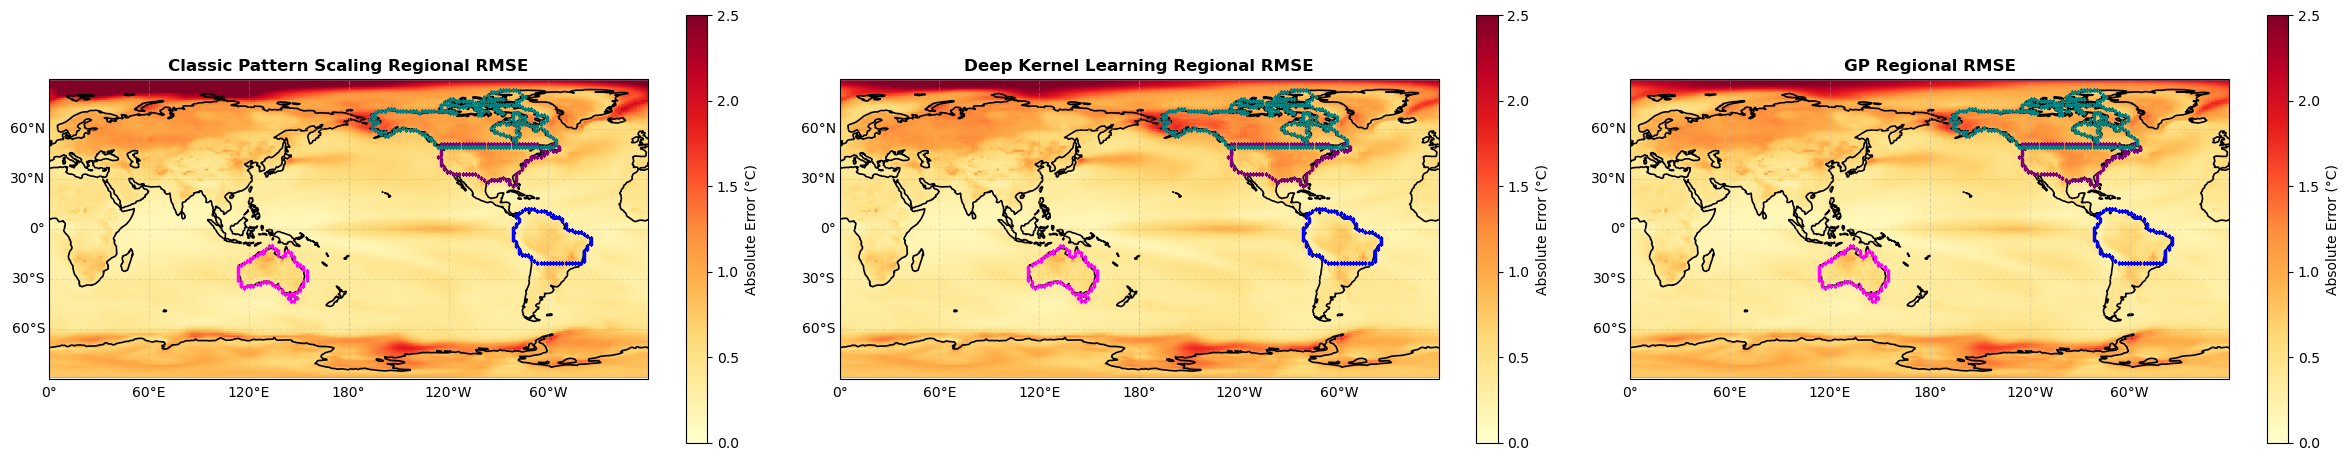

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 1. CRUCIAL: Define a Pacific-centered map projection (shifted by 180 degrees)
map_proj = ccrs.PlateCarree(central_longitude=180)

# Pass this specific projection parameter to  subplots setup
fig, axes = plt.subplots(1, 3, figsize=(24, 6), subplot_kw={'projection': map_proj})

vmax_error = 2.5
cbar_label = 'Absolute Error (°C)'
fmt_cbar = None  

# 2. Update  data coordinates window to match  0-360 longitudinal data grid system
data_extent = [0, 360, -90, 90] 

# Render Spatial Heatmaps
im0 = axes[0].imshow(baseline_rmse, cmap='YlOrRd', origin='lower', extent=data_extent, vmin=0, vmax=vmax_error, transform=ccrs.PlateCarree())
axes[0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
cbar0 = fig.colorbar(im0, ax=axes[0], label=cbar_label, shrink=0.75, format=fmt_cbar)

im1 = axes[1].imshow(lstm_rmse, cmap='YlOrRd', origin='lower', extent=data_extent, vmin=0, vmax=vmax_error, transform=ccrs.PlateCarree())
axes[1].set_title('Deep Kernel Learning Regional RMSE', fontweight='bold', fontsize=12)
cbar1 = fig.colorbar(im1, ax=axes[1], label=cbar_label, shrink=0.75, format=fmt_cbar)

im2 = axes[2].imshow(gp_rmse, cmap='YlOrRd', origin='lower', extent=data_extent, vmin=0, vmax=vmax_error, transform=ccrs.PlateCarree())
axes[2].set_title('GP Regional RMSE', fontweight='bold', fontsize=12)
cbar2 = fig.colorbar(im2, ax=axes[2], label=cbar_label, shrink=0.75, format=fmt_cbar)

# --- Apply Cartopy Coastlines and View Frame ---
for ax in axes:
    # 3. Tell the axes to zoom out to global view limits relative to the map's projection system
    ax.set_global() 
    
    # 4. Draw the background coastlines in solid black
    ax.coastlines(resolution='110m', color='black', linewidth=1.2, zorder=2)

remove_ocean = True
if plot_outlines:
    land_regions_grid = regionmask.defined_regions.ar6.land.mask(regridded.lon.values, regridded.lat.values)
    mask_values = land_regions_grid.values
    for i in range(len(conts)):
        target_ids = conts[i]
        combined_region_mask = np.isin(mask_values, target_ids)
        if remove_ocean:
            combined_region_mask = combined_region_mask & ~ocean_mask.values
        
        thick_mask = binary_dilation(combined_region_mask, iterations=1)
        outline_mask = thick_mask & ~combined_region_mask
        
        # Extract boundary locations
        y_indices, x_indices = np.where(outline_mask)
        
        # Map the matrix pixel indexes back onto true lat/lon degrees
        lon_degrees = regridded.lon.values[x_indices]
        lat_degrees = regridded.lat.values[y_indices]
        
        # Overlay  custom colored scatter coordinates cleanly on top of the black line (zorder=5)
        # CRUCIAL: transform=ccrs.PlateCarree() stays here because  input data arrays are still raw degrees
        for ax in axes:
            ax.scatter(lon_degrees, lat_degrees, color=colours[i], s=4, marker='s', zorder=5, transform=ccrs.PlateCarree())

# Apply clean geo-aware labels and formatting metrics
for ax in axes:
    # 1. Generate geo-aware gridlines with edge labels enabled
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3, linestyle='--')
    
    # 2. Suppress the labels on the top and right edges to keep the plot clean
    gl.top_labels = False
    gl.right_labels = False
    
    # 3. Style the coordinate label fonts to match  titles
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}


    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


# Apply clean labels and formatting metrics
'''for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
   ''' 
plt.tight_layout()
plt.show()


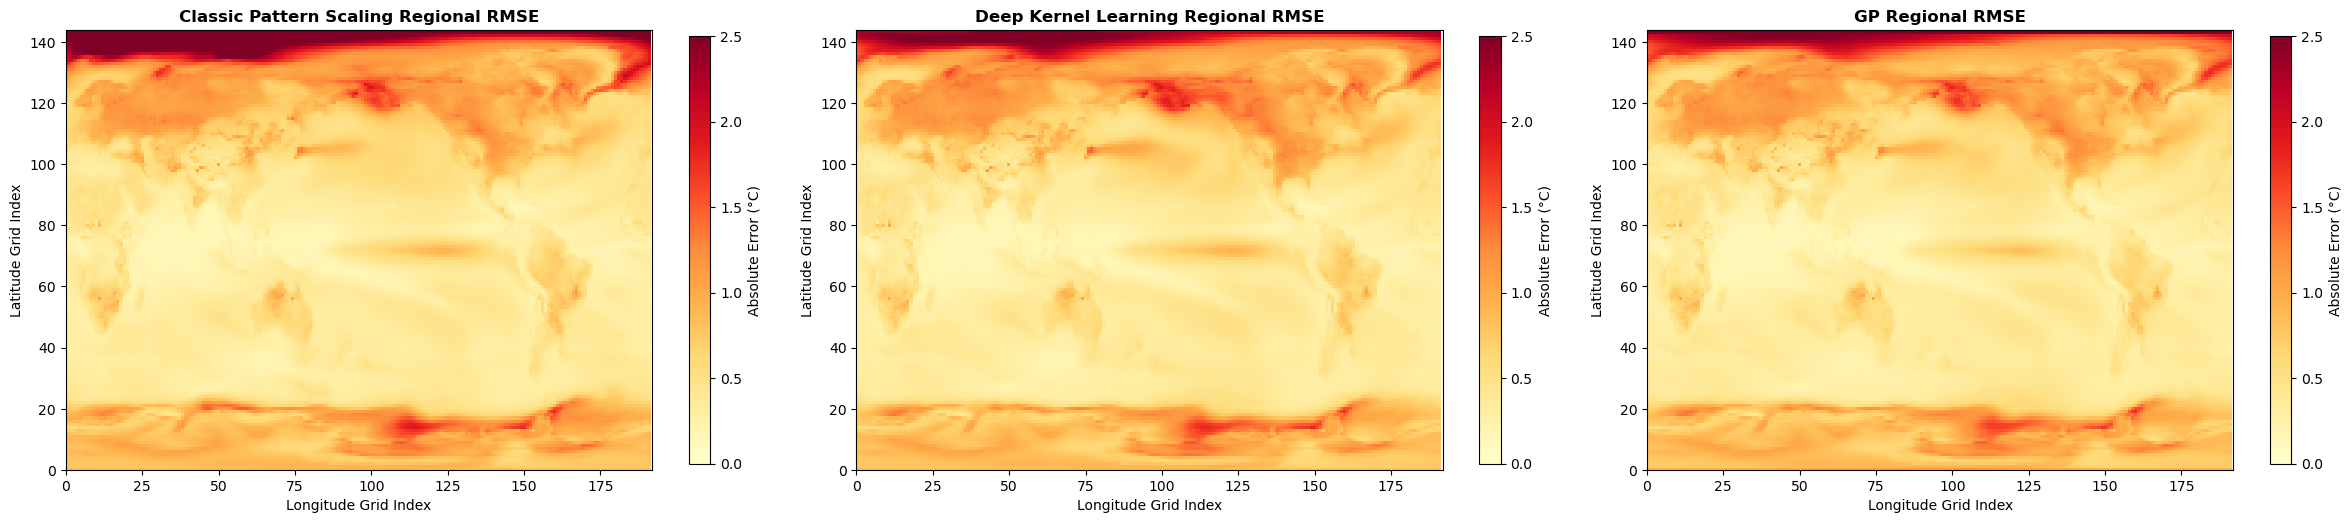

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

vmax_error = 2.5
cbar_label = 'Absolute Error (°C)'
fmt_cbar = None  

# Render Plot 1: Classic Pattern Scaling Map
im0 = axes[0].imshow(baseline_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
cbar0 = fig.colorbar(im0, ax=axes[0], label=cbar_label, shrink=0.75, format=fmt_cbar)

# Render Plot 2: Deep Kernel Learning Map
im1 = axes[1].imshow(lstm_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[1].set_title('Deep Kernel Learning Regional RMSE', fontweight='bold', fontsize=12)
cbar1 = fig.colorbar(im1, ax=axes[1], label=cbar_label, shrink=0.75, format=fmt_cbar)

# Render Plot 3: Pure GP Map
im2 = axes[2].imshow(gp_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[2].set_title('GP Regional RMSE', fontweight='bold', fontsize=12)
# FIX: Corrected  template cbar1/im1 overwrite typo on the 3rd plot
cbar2 = fig.colorbar(im2, ax=axes[2], label=cbar_label, shrink=0.75, format=fmt_cbar)

for ax in axes:
    ax.set_xlabel('Longitude Grid Index')
    ax.set_ylabel('Latitude Grid Index')
    ax.set_xlim(0, 192)  # Explicitly locks  horizontal matrix viewport
    ax.set_ylim(0, 144)  # Explicitly locks  vertical matrix viewport
    ax.set_aspect('equal', adjustable='box')
    
plt.tight_layout()
plt.show()

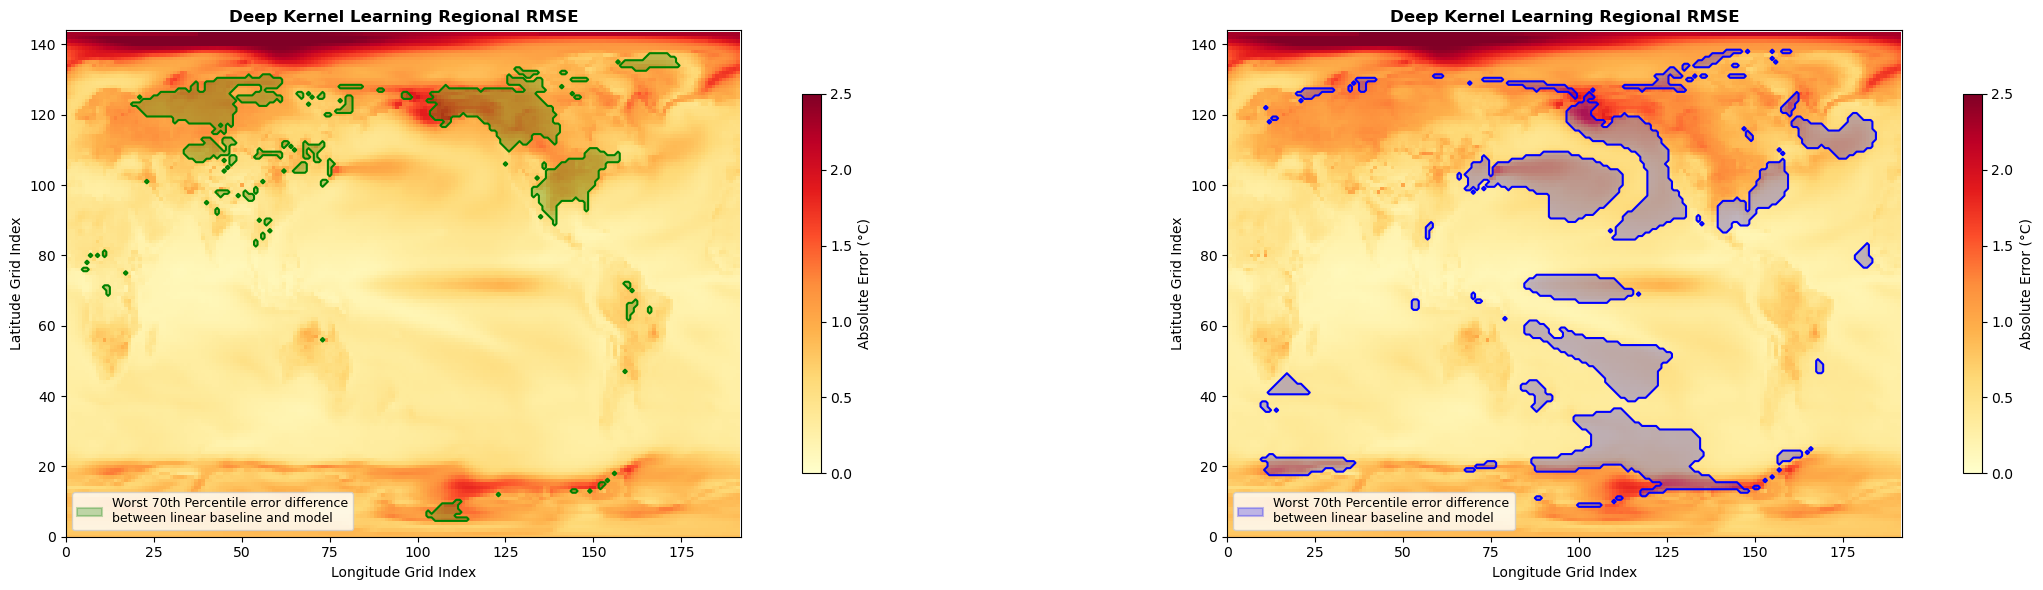

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # FIX: Required to render the proxy legends correctly

# Convert  mask to a clean boolean array (True where it is ocean)
is_ocean = (ocean_mask.values == True)

# Apply np.where(condition, value_if_true, value_if_false)
# We want: if it IS ocean, turn it to NaN; if it is NOT ocean (land), keep the RMSE value.
land_baseline = np.where(is_ocean, np.nan, baseline_rmse)
land_lstm     = np.where(is_ocean, np.nan, lstm_rmse)
land_gp       = np.where(is_ocean, np.nan, gp_rmse)

# 1. Calculate where LSTM is worse than Baseline (Positive values = LSTM has higher error)
error_difference = land_lstm - land_baseline

# 2. Extract the 90th percentile threshold *strictly* from areas where LSTM is worse
# (Using a mask ensures we don't skew the percentile with areas where LSTM is better)
thresh_percentile = 70
worse_performance_values = error_difference[error_difference > 0]
if len(worse_performance_values) > 0:
    threshold_diff = np.percentile(worse_performance_values, thresh_percentile)
    # 3. Create a binary mask where the performance penalty is in the top 10%
    mask_worse_performing = np.where(error_difference >= threshold_diff, 1, 0)
else:
    # Fallback if LSTM is universally better everywhere
    mask_worse_performing = np.zeros_like(error_difference)

#######

# Do the same for sea pixels
sea_baseline = np.where(~is_ocean, np.nan, baseline_rmse)
sea_lstm     = np.where(~is_ocean, np.nan, lstm_rmse)
sea_gp       = np.where(~is_ocean, np.nan, gp_rmse)

sea_difference = sea_lstm - sea_baseline
worse_performance_values = sea_difference[sea_difference > 0]
if len(worse_performance_values) > 0:
    threshold_diff = np.percentile(worse_performance_values, thresh_percentile)
    sea_mask = np.where(sea_difference >= threshold_diff, 1, 0)
else:
    sea_mask = np.zeros_like(sea_difference)

#######

fig, axes = plt.subplots(1, 2, figsize=(24, 6))

vmax_error = 2.5
cbar_label = 'Absolute Error (°C)'
fmt_cbar = None  


# Render Deep Kernel Learning Map
im0 = axes[0].imshow(lstm_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[0].set_title('Deep Kernel Learning Regional RMSE', fontweight='bold', fontsize=12)
cbar0 = fig.colorbar(im0, ax=axes[0], label=cbar_label, shrink=0.75, format=fmt_cbar) # FIX: Maps im0 to axes[0] instead of im1 to avoid overlapping figure warnings

# Render Deep Kernel Learning Map
im1 = axes[1].imshow(lstm_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=vmax_error)
axes[1].set_title('Deep Kernel Learning Regional RMSE', fontweight='bold', fontsize=12)
cbar1 = fig.colorbar(im1, ax=axes[1], label=cbar_label, shrink=0.75, format=fmt_cbar)

for ax in axes:
    ax.set_xlabel('Longitude Grid Index')
    ax.set_ylabel('Latitude Grid Index')
    ax.set_xlim(0, 192)  
    ax.set_ylim(0, 144)  
    ax.set_aspect('equal', adjustable='box')


# 4. Overlay the exact same penalty mask onto BOTH plots to compare geographic locations
# This draws a clean, solid outline with a translucent color fill inside
if len(worse_performance_values) > 0:
    # --- Plot 0: LSTM Worse-Performing Mask ---
    axes[0].contourf(mask_worse_performing, levels=[0.5, 1.5], colors='green', alpha=0.25)
    axes[0].contour(mask_worse_performing, levels=[0.5], colors='green', linewidths=1.5, linestyles='-')
    
    # Proxy handles build the legend layout manually to bypass contour limitations
    # Splitting  long string with \n guarantees the legend doesn't clip off the right edge of the plot page
    green_patch = mpatches.Patch(facecolor='green', edgecolor='green', alpha=0.25, linewidth=1.5,
                                 label="Worst 70th Percentile error difference\nbetween linear baseline and model")
    axes[0].legend(handles=[green_patch], loc='lower left', fontsize=9)

    # --- Plot 1: Sea Mask ---
    axes[1].contourf(sea_mask, levels=[0.5, 1.5], colors='blue', alpha=0.25)
    axes[1].contour(sea_mask, levels=[0.5], colors='blue', linewidths=1.5, linestyles='-')
    
    # Matching proxy design block for the ocean overlay panel
    blue_patch = mpatches.Patch(facecolor='blue', edgecolor='blue', alpha=0.25, linewidth=1.5,
                                label="Worst 70th Percentile error difference\nbetween linear baseline and model")
    axes[1].legend(handles=[blue_patch], loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()
